# Reviewer Responses Implementation
This notebook contains the code implementations for the requested changes (Points 2, 6, 7, and 8) to ensure the original notebooks remain unchanged and the additions are easy to visualize and review.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('MASTER_with_sentiment.csv')
print(f"Loaded dataset with {len(df)} rows.")

Loaded dataset with 100875 rows.


## Point 2: Lexicon Validation
Generate a random sample of 200 comments (100 from Product World, 100 from Identity World) for manual coding.

In [2]:
# Sample 100 from each source
prod_sample = df[df['source'] == 'product'].sample(n=100, random_state=42)
gen_sample = df[df['source'] == 'gender'].sample(n=100, random_state=42)
sample_df = pd.concat([prod_sample, gen_sample])

# Add empty columns for manual coding
sample_df['manual_inclusive'] = ''
sample_df['manual_exclusive'] = ''

# Keep relevant columns
columns_to_keep = ['source', 'subreddit', 'post_id', 'comment_id', 'text_to_analyze', 
                   'language_category', 'manual_inclusive', 'manual_exclusive']
sample_df = sample_df[columns_to_keep]

# Save to CSV
sample_df.to_csv('lexicon_validation_sample.csv', index=False)
print("Saved 200 random comments to 'lexicon_validation_sample.csv'.")

Saved 200 random comments to 'lexicon_validation_sample.csv'.


## Point 6: Statistical Testing
Perform Mann-Whitney U tests for sentiment comparisons and a Chi-Square test for term frequencies.

In [3]:
print("--- Mann-Whitney U Test: Dysphoria vs Sustainability ---")
group_dysphoria = df[df['mentions_identity_stigma'] > 0]['sentiment_compound']
group_sustainability = df[df['mentions_sustainability'] > 0]['sentiment_compound']
u_stat, p_val = stats.mannwhitneyu(group_dysphoria, group_sustainability, alternative='two-sided')
n1, n2 = len(group_dysphoria), len(group_sustainability)
r = 1 - (2 * u_stat) / (n1 * n2) # Rank-biserial correlation
print(f"U={u_stat:.2f}, p={p_val:.4e}, effect size (r)={r:.4f}")

print("\n--- Mann-Whitney U Test: Product vs Identity World ---")
group_prod = df[df['source'] == 'product']['sentiment_compound']
group_ident = df[df['source'] == 'gender']['sentiment_compound']
u_stat2, p_val2 = stats.mannwhitneyu(group_prod, group_ident, alternative='two-sided')
n1, n2 = len(group_prod), len(group_ident)
r2 = 1 - (2 * u_stat2) / (n1 * n2)
print(f"U={u_stat2:.2f}, p={p_val2:.4e}, effect size (r)={r2:.4f}")

print("\n--- Chi-square Test: Inclusive vs Exclusive terms across communities ---")
prod_inc = df[df['source'] == 'product']['total_inclusive_lang'].sum()
prod_exc = df[df['source'] == 'product']['total_exclusive_lang'].sum()
ident_inc = df[df['source'] == 'gender']['total_inclusive_lang'].sum()
ident_exc = df[df['source'] == 'gender']['total_exclusive_lang'].sum()

obs = np.array([[prod_inc, prod_exc], [ident_inc, ident_exc]])
chi2, p, dof, expected = stats.chi2_contingency(obs)
n = obs.sum()
v = np.sqrt(chi2 / (n * (min(obs.shape)-1))) # Cramer's V
print(f"Chi2={chi2:.2f}, p={p:.4e}, Cramer's V={v:.4f}")
print(f"Observed counts (Product [Inc, Exc], Identity [Inc, Exc]):\n{obs}")

--- Mann-Whitney U Test: Dysphoria vs Sustainability ---
U=13240695.50, p=5.8940e-27, effect size (r)=0.1353

--- Mann-Whitney U Test: Product vs Identity World ---


U=1063267950.00, p=5.1045e-40, effect size (r)=-0.0540

--- Chi-square Test: Inclusive vs Exclusive terms across communities ---


Chi2=11.23, p=8.0540e-04, Cramer's V=0.0247
Observed counts (Product [Inc, Exc], Identity [Inc, Exc]):
[[   28  7334]
 [   87 10935]]


## Point 7: Sample Sizes in Figures
Recreate the sentiment figures with n= labels included on the axes.

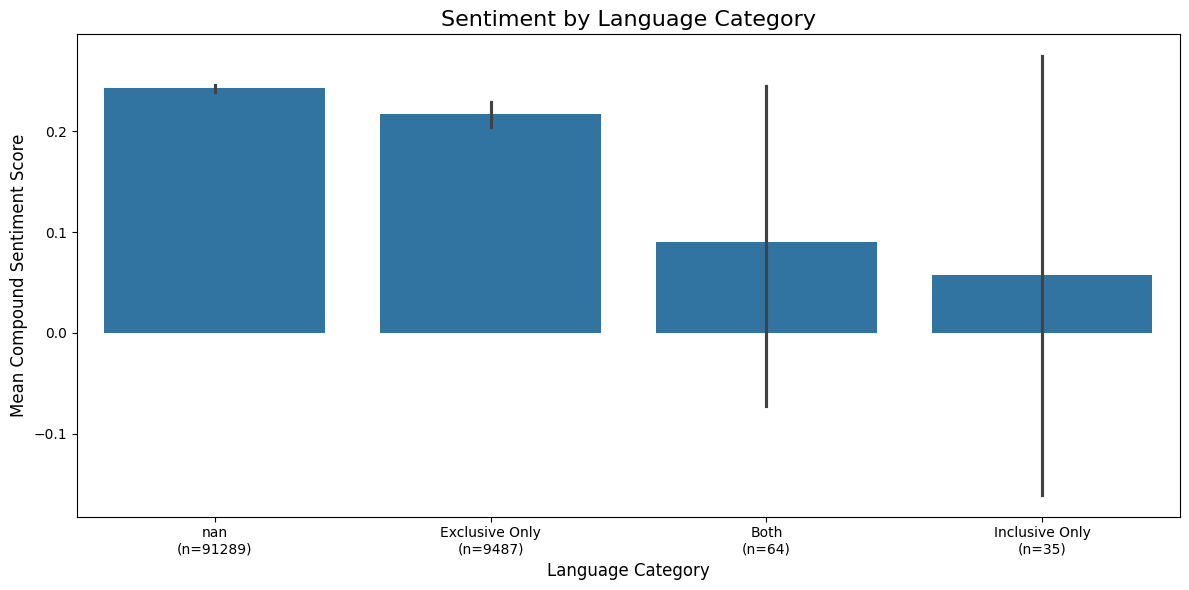

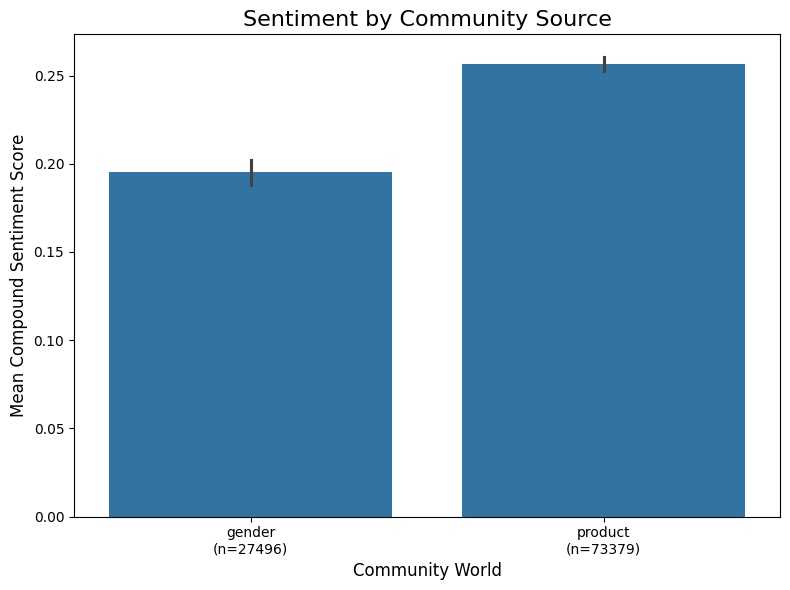

In [4]:
def add_n_to_labels(dataframe, cat_col):
    counts = dataframe[cat_col].value_counts(dropna=False)
    return dataframe[cat_col].apply(lambda x: f"{x}\n(n={counts.get(x, 0)})")

# Create new columns with updated labels
df['language_category_n'] = add_n_to_labels(df, 'language_category')
df['source_n'] = add_n_to_labels(df, 'source')

# Plot 1: Sentiment by Language Category
plt.figure(figsize=(12, 6))
sns.barplot(x='language_category_n', y='sentiment_compound', data=df)
plt.title("Sentiment by Language Category", fontsize=16)
plt.xlabel("Language Category", fontsize=12)
plt.ylabel("Mean Compound Sentiment Score", fontsize=12)
plt.tight_layout()
plt.savefig("plot_sentiment_by_language_with_n.jpg", format='jpg')
plt.show()

# Plot 2: Sentiment by Community Source
plt.figure(figsize=(8, 6))
sns.barplot(x='source_n', y='sentiment_compound', data=df)
plt.title("Sentiment by Community Source", fontsize=16)
plt.xlabel("Community World", fontsize=12)
plt.ylabel("Mean Compound Sentiment Score", fontsize=12)
plt.tight_layout()
plt.savefig("plot_sentiment_by_source_with_n.jpg", format='jpg')
plt.show()

## Point 8: The 0.03% Figure
Calculate the absolute comment counts behind the 0.03% inclusive language figure.

In [5]:
inclusive_df = df[df['language_category'] == 'Inclusive Only']
counts = inclusive_df['subreddit'].value_counts()

print("Absolute comment counts behind the 0.03% 'Inclusive Only' figure:")
print("-" * 50)
print(counts)
print("-" * 50)
print(f"Total: {counts.sum()}")

Absolute comment counts behind the 0.03% 'Inclusive Only' figure:
--------------------------------------------------
subreddit
MtF               9
ftm               6
Periods           6
lgbt              3
menstrualcups     3
menstruation      2
asktransgender    2
trans             1
AskLGBT           1
NonBinary         1
WomensHealth      1
Name: count, dtype: int64
--------------------------------------------------
Total: 35
